Dataset Info
Shape: (569, 30)
Classes (0 = Benign, 1 = Malignant): [0 1]


1. TRAIN-TEST SPLIT (BASELINE)
Accuracy: 0.9561


2. INSTABILITY OF TRAIN-TEST SPLIT
Run 1: Accuracy = 0.9474
Run 2: Accuracy = 0.9298
Run 3: Accuracy = 0.9561
Run 4: Accuracy = 0.9123
Run 5: Accuracy = 0.9561


3. K-FOLD CROSS VALIDATION
Scores: [0.9561 0.9649 0.9386 0.9737 0.9204]
Mean Accuracy: 0.9507


4. STRATIFIED K-FOLD
---------------------
Scores: [0.9649 0.9211 0.9649 0.9474 0.9735]
Mean Accuracy: 0.9543


5. BOOTSTRAP SAMPLING (10 SAMPLES)
-----------------------------------
Bootstrap Mean Accuracy: 0.9576


6. FINAL COMPARISON
--------------------
Train-Test Split          : 0.9561
K-Fold (5)                : 0.9507
Stratified K-Fold (5)     : 0.9543
Bootstrap (10)            : 0.9576



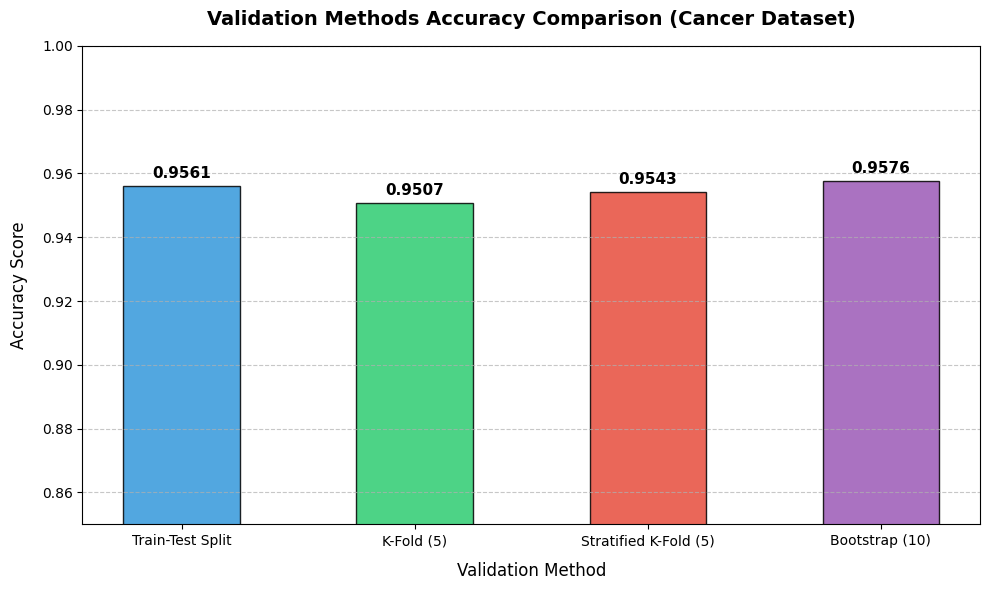

In [12]:
# CROSS VALIDATION TECHNIQUES - FULL DEMO (Using Cancer_Prediction.csv)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    cross_val_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

# 1. LOAD DATASET FROM CSV (day7 folder)

# Path to the dataset in the day7 folder
csv_path = '../day7/Cancer_Prediction.csv'  # or r'c:/Users/Administrator/Desktop/DE/day7/Cancer_Prediction.csv'
df = pd.read_csv(csv_path)

# Drop trailing empty column (if present) and ID column
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
X = df.drop(columns=['id', 'diagnosis'])

# Encode target labels ('M' -> 1, 'B' -> 0)
y = LabelEncoder().fit_transform(df['diagnosis'])

print("Dataset Info")
print("Shape:", X.shape)
print("Classes (0 = Benign, 1 = Malignant):", np.unique(y))
print("\n" + "="*50)

# 2. TRAIN-TEST SPLIT (BASELINE)

print("\n1. TRAIN-TEST SPLIT (BASELINE)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

tt_accuracy = model.score(X_test, y_test)

print("Accuracy:", round(tt_accuracy, 4))
print("\n" + "="*50)

# 3. INSTABILITY DEMO

print("\n2. INSTABILITY OF TRAIN-TEST SPLIT")

for i in range(5):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f"Run {i+1}: Accuracy = {round(acc, 4)}")

print("\n" + "="*50)

# 4. K-FOLD CROSS VALIDATION

print("\n3. K-FOLD CROSS VALIDATION")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_scores = cross_val_score(model, X, y, cv=kf)

print("Scores:", np.round(kf_scores, 4))
print("Mean Accuracy:", round(kf_scores.mean(), 4))

print("\n" + "="*50)

# 5. STRATIFIED K-FOLD

print("\n4. STRATIFIED K-FOLD")
print("---------------------")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_scores = cross_val_score(model, X, y, cv=skf)

print("Scores:", np.round(skf_scores, 4))
print("Mean Accuracy:", round(skf_scores.mean(), 4))

print("\n" + "="*50)

# 6. BOOTSTRAP SAMPLING

print("\n5. BOOTSTRAP SAMPLING (10 SAMPLES)")
print("-----------------------------------")

boot_accs = []
for i in range(10):
    X_sample, y_sample = resample(X, y, replace=True, n_samples=len(X))
    model.fit(X_sample, y_sample)
    acc = accuracy_score(y, model.predict(X))
    boot_accs.append(acc)

boot_accuracy = np.mean(boot_accs)
print("Bootstrap Mean Accuracy:", round(boot_accuracy, 4))

print("\n" + "="*50)

# 7. FINAL COMPARISON

print("\n6. FINAL COMPARISON")
print("--------------------")

results = {
    "Train-Test Split": tt_accuracy,
    "K-Fold (5)": kf_scores.mean(),
    "Stratified K-Fold (5)": skf_scores.mean(),
    "Bootstrap (10)": boot_accuracy
}

for method, score in results.items():
    print(f"{method:<25} : {round(score, 4)}")

print("\n" + "="*50)

# 8. VISUALIZATION GRAPH

methods = list(results.keys())
accuracies = list(results.values())
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, accuracies, color=colors, edgecolor='black', alpha=0.85, width=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.0015, f"{yval:.4f}", 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Validation Methods Accuracy Comparison (Cancer Dataset)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Validation Method', fontsize=12, labelpad=10)
plt.ylabel('Accuracy Score', fontsize=12, labelpad=10)
plt.ylim(0.85, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [2]:
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import resample

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

model = LogisticRegression(max_iter=5000)

In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=kf)

print("\nK-Fold Scores:", scores)
print("Mean Accuracy:", scores.mean())


K-Fold Scores: [0.95614035 0.96491228 0.93859649 0.97368421 0.92035398]
Mean Accuracy: 0.9507374631268437


In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=skf)

print("\nStratified K-Fold Scores:", scores)
print("Mean Accuracy:", scores.mean())


Stratified K-Fold Scores: [0.96491228 0.92105263 0.96491228 0.94736842 0.97345133]
Mean Accuracy: 0.9543393882937432


In [5]:
accuracies = []

for i in range(10):
    X_sample, y_sample = resample(X, y, replace=True, n_samples=len(X))

    model.fit(X_sample, y_sample)
    y_pred = model.predict(X)

    acc = accuracy_score(y, y_pred)
    accuracies.append(acc)

print("\nBootstrap Accuracies:", accuracies)
print("Mean Accuracy:", np.mean(accuracies))


Bootstrap Accuracies: [0.9560632688927944, 0.9543057996485061, 0.9525483304042179, 0.9543057996485061, 0.9507908611599297, 0.9578207381370826, 0.9630931458699473, 0.9578207381370826, 0.9560632688927944, 0.9595782073813708]
Mean Accuracy: 0.9562390158172234


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[34  1]
 [ 4 75]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93        35
           1       0.99      0.95      0.97        79

    accuracy                           0.96       114
   macro avg       0.94      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [7]:
scores = cross_val_score(model, X, y, cv=5)

print("\nSingle Model Evaluation")
print("Mean:", scores.mean())
print("Std Dev:", scores.std())


Single Model Evaluation
Mean: 0.9507995652848935
Std Dev: 0.01804054330253301


In [8]:
model1 = LogisticRegression(max_iter=5000)
model2 = DecisionTreeClassifier()

scores1 = cross_val_score(model1, X, y, cv=5)
scores2 = cross_val_score(model2, X, y, cv=5)

print("\nModel Comparison")
print("Logistic Regression:", scores1.mean())
print("Decision Tree:", scores2.mean())


Model Comparison
Logistic Regression: 0.9507995652848935
Decision Tree: 0.924375097034622


In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores1 = []
scores2 = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model1.fit(X_train, y_train)
    model2.fit(X_train, y_train)

    scores1.append(model1.score(X_test, y_test))
    scores2.append(model2.score(X_test, y_test))

print("\nPaired Comparison")
print("Model1 Scores:", scores1)
print("Model2 Scores:", scores2)

diff = np.array(scores1) - np.array(scores2)
print("Difference:", diff)


Paired Comparison
Model1 Scores: [0.956140350877193, 0.9649122807017544, 0.9385964912280702, 0.9736842105263158, 0.9203539823008849]
Model2 Scores: [0.9385964912280702, 0.9473684210526315, 0.9298245614035088, 0.9385964912280702, 0.9469026548672567]
Difference: [ 0.01754386  0.01754386  0.00877193  0.03508772 -0.02654867]


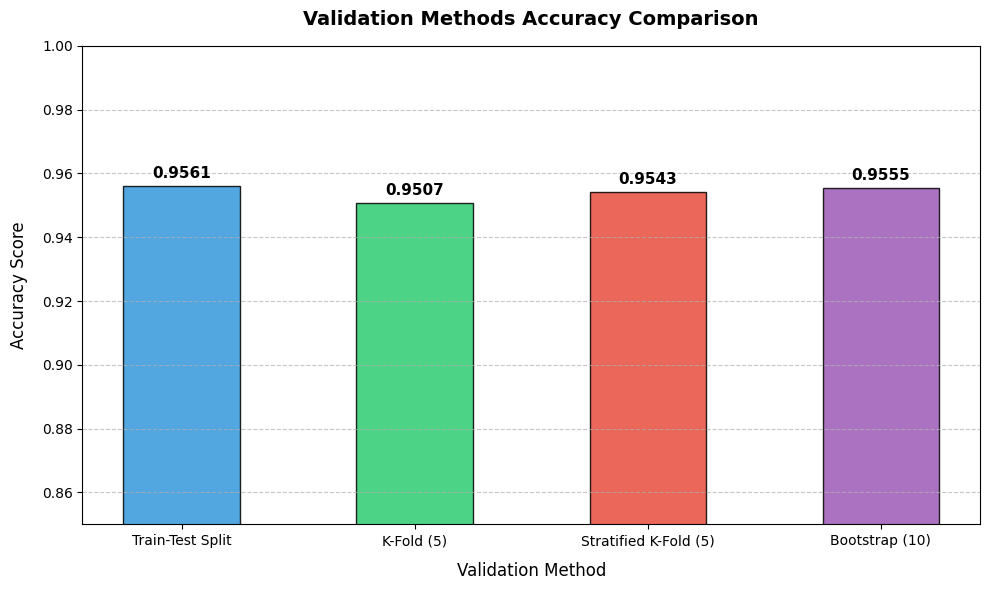

In [10]:
# =========================================================
# 9. VISUALIZATION OF ALL VALIDATION METHODS
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

# 1. Load Data & Initialize Model
data = load_breast_cancer()
X, y = data.data, data.target
model = LogisticRegression(max_iter=5000)

# 2. Train-Test Split (Baseline)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
tt_acc = model.score(X_test, y_test)

# 3. K-Fold Cross Validation (5 Folds)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_acc = cross_val_score(model, X, y, cv=kf).mean()

# 4. Stratified K-Fold Cross Validation (5 Folds)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_acc = cross_val_score(model, X, y, cv=skf).mean()

# 5. Bootstrap Resampling (10 Samples)
boot_accs = []
for i in range(10):
    X_sample, y_sample = resample(X, y, replace=True, n_samples=len(X))
    model.fit(X_sample, y_sample)
    boot_accs.append(accuracy_score(y, model.predict(X)))
boot_acc = np.mean(boot_accs)

# 6. Create Bar Chart Visualization
methods = ['Train-Test Split', 'K-Fold (5)', 'Stratified K-Fold (5)', 'Bootstrap (10)']
accuracies = [tt_acc, kf_acc, skf_acc, boot_acc]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, accuracies, color=colors, edgecolor='black', alpha=0.85, width=0.5)

# Add exact score values on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.0015, f"{yval:.4f}", 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Validation Methods Accuracy Comparison', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Validation Method', fontsize=12, labelpad=10)
plt.ylabel('Accuracy Score', fontsize=12, labelpad=10)
plt.ylim(0.85, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
